# PREDICTIVE ML MODEL TRAINING FOR PROCESS PUMP THROUGH WATER PUMP DATASET

### Set-up & Imports

In [1]:
# 0/ Setup & Imports
import warnings
warnings.filterwarnings('ignore')


import os
import glob
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt


from sklearn.feature_selection import mutual_info_regression as MIR
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.preprocessing import StandardScaler
from scipy.stats import wasserstein_distance
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from scipy.stats import ks_2samp



# Reproducibility
np.random.seed(42)

# Display options for readable, aligned outputs
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Small helpers for tidy logs
def print_header(title: str):
    line = '=' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_footer(title: str):
    line = '-' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_kv(pairs):
    # pairs: list of (key, value)
    width = max(len(str(k)) for k, _ in pairs) if pairs else 0
    for k, v in pairs:
        print(f"{str(k).ljust(width)} : {v}")

def R_MSE(y_true, y_pred):
    return np.sqrt(MSE(y_true, y_pred))

def get_numeric_sensor_cols(df: pd.DataFrame, exclude_cols: set) -> list:
    cols = []
    for c in df.columns:
        if c in exclude_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols

# store results for comparison of trained models
results_dict = {}

# data directory
main_path = os.path.basename(os.getcwd())
if main_path != "pump_sensor&rul_hrs data":
    data_dir = "pump_sensor&rul_hrs data"  
    os.chdir(data_dir)
    

print_footer("SETUP AND IMPORTS COMPLETE")


----------------------------------------------------------------------
SETUP AND IMPORTS COMPLETE
----------------------------------------------------------------------


## 1) Dataset Load & Basic Inspection

In [2]:
# 1/ Dataset Load & Basic Inspection

print_header("1/ DATASET LOAD & BASIC INSPECTION")

def summarize_df(name, df):
    rows, cols = df.shape
    dtypes = df.dtypes.value_counts()
    dtype_str = ", ".join([f"{dt}: {cnt}" for dt, cnt in dtypes.items()])
    pairs = [
                (f"{name} rows", rows),
                (f"{name} cols", cols),
                (f"{name} dtypes", dtype_str),
            ]
    print_kv(pairs)

# load dataset
df_merged = pd.read_csv("pump_rul_hrs.csv")

#basic info
summarize_df("Merged DataFrame", df_merged)

print("-" * 40)
print("\nColumns:")
print(df_merged.columns.tolist())
print("-" * 40)

print("\nDescription:")
print(df_merged.describe().T)
print("-" * 40)


print("\nNull Values:")
null_df_merged = df_merged.isnull().sum().sum()
print_kv([("NULL Total", null_df_merged)])
print("-" * 40)

print("\nDuplicate Rows:")
print(df_merged.duplicated().sum())
print("-" * 40)

print("\nUnique Values")
u_df_merged = df_merged['Unnamed: 0'].nunique()
print_kv([("Unique Total", u_df_merged)])
print("-" * 40)




1/ DATASET LOAD & BASIC INSPECTION
Merged DataFrame rows   : 166441
Merged DataFrame cols   : 53
Merged DataFrame dtypes : float64: 51, int64: 1, object: 1
----------------------------------------

Columns:
['Unnamed: 0', 'timestamp', 'sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_51', 'rul']
----------------------------------------

Description:
               count       mean        std     min  

## 2) Feature Selection & Preprocessing

In [3]:
# 2/ Feature Selection and Preprocessing

print_header("2/ FEATURE SELECTION AND PREPROCESSING")
# Function to get numeric and categorical columns
def get_column_types(df):
    numeric_cols = []
    categorical_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)
    return numeric_cols, categorical_cols

# Function to drop constant columns
def drop_constant_columns(df, cols):
    dropped = []
    for col in cols:
        if df[col].nunique() == 1:
            df = df.drop(col, axis=1)
            dropped.append(col)
    return df, dropped

# Main processing
numeric_cols, categorical_cols = get_column_types(df_merged)

# Remove ID and timestamp columns
cols_to_remove = ['Unnamed: 0', 'timestamp']
sensor_cols = [col for col in numeric_cols if col not in cols_to_remove and col != 'rul']

# Drop constant columns from sensor features
df_sensors, dropped_constants = drop_constant_columns(df_merged, sensor_cols)

# Drop ID and timestamp columns from df_sensors 
df_sensors = df_sensors.drop(cols_to_remove, axis=1)


# Prepare X and y
X = df_sensors[sensor_cols]
y = df_merged['rul']

# Validation
print("Feature Selection Validation")
print("-" * 40)
print_kv([
            ("Numeric columns", len(numeric_cols)),
            ("Categorical columns", len(categorical_cols)),
            ("Sensor columns (before drop)", len(sensor_cols)),
            ("Dropped constant columns", len(dropped_constants)),
            ("Final X shape", X.shape),
            ("Final y shape", y.shape),
            ("Dropped constant columns:", dropped_constants)
        ])

assert not any(col in X.columns for col in cols_to_remove), "ID/timestamp columns found in X!"
assert y.name == 'rul', "Target column y is not 'rul'!"

print_footer("FEATURE SELECTION COMPLETE")


2/ FEATURE SELECTION AND PREPROCESSING
Feature Selection Validation
----------------------------------------
Numeric columns              : 52
Categorical columns          : 1
Sensor columns (before drop) : 50
Dropped constant columns     : 0
Final X shape                : (166441, 50)
Final y shape                : (166441,)
Dropped constant columns:    : []

----------------------------------------------------------------------
FEATURE SELECTION COMPLETE
----------------------------------------------------------------------


## 3) Feature Engineering

In [4]:
# 3/ Rolling Mean and Std Feature Engineering

print_header("3/ ROLLING MEAN AND STD FEATURE ENGINEERING")

def add_rolling_features(df, cols, window=5):
    for col in cols:
        df[f"{col}_roll_mean"] = df[col].rolling(window=window, min_periods=1).mean()
        df[f"{col}_roll_std"] = df[col].rolling(window=window, min_periods=1).std()
    return df

# Forward fill first
X_ffill = X.copy().ffill()

# Apply rolling features
X_features = add_rolling_features(X_ffill, X_ffill.columns, window=5)

# Forward and backward fill for any remaining NaN
X_features = X_features.ffill().bfill()

# If still NaN exists, fill with mean
imputer = SimpleImputer(strategy='mean')
X_features_imputed = pd.DataFrame(imputer.fit_transform(X_features), columns=X_features.columns)

# Validation for NaN
print("Any NaN left in X_features_imputed:", X_features_imputed.isnull().sum().sum())

# save as CSV
X_features_imputed['rul'] = y.values
X_features_imputed.to_csv('pump_features_rul.csv', index=False)
print("Saved to pump_features_rul.csv")

# Mutual Information
mi_scores = MIR(X_features_imputed, y)
mi_df = pd.DataFrame({'feature': X_features_imputed.columns, 'mi_score': mi_scores})
mi_df = mi_df[mi_df['feature'] != 'rul']  # 'rul' removed
mi_df = mi_df.sort_values(by='mi_score', ascending=False)

print("\nFeature Engineering Validation")
print("-" * 40)
print("Shape of X_features_imputed:", X_features_imputed.shape)
print("First 3 rows:")
print(X_features_imputed.head(3))
print("\nTop 10 features by Mutual Information:")
print(mi_df.head(10))

print_footer("FEATURE ENGINEERING COMPLETED AND SAVED")


3/ ROLLING MEAN AND STD FEATURE ENGINEERING
Any NaN left in X_features_imputed: 0
Saved to pump_features_rul.csv

Feature Engineering Validation
----------------------------------------
Shape of X_features_imputed: (166441, 151)
First 3 rows:
   sensor_00  sensor_01  sensor_02  sensor_03  sensor_04  sensor_05  sensor_06  sensor_07  sensor_08  sensor_09  \
0      2.465     47.092     53.212     46.311    634.375     76.460     13.411     16.131     15.567     15.054   
1      2.465     47.092     53.212     46.311    634.375     76.460     13.411     16.131     15.567     15.054   
2      2.445     47.352     53.212     46.398    638.889     73.546     13.325     16.037     15.618     15.010   

   sensor_10  sensor_11  sensor_12  sensor_13  sensor_14  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  \
0     37.227     47.524     31.117      1.681    419.575    461.878    466.328      2.565    665.399    398.986   
1     37.227     47.524     31.117      1.681    419.575    461.8

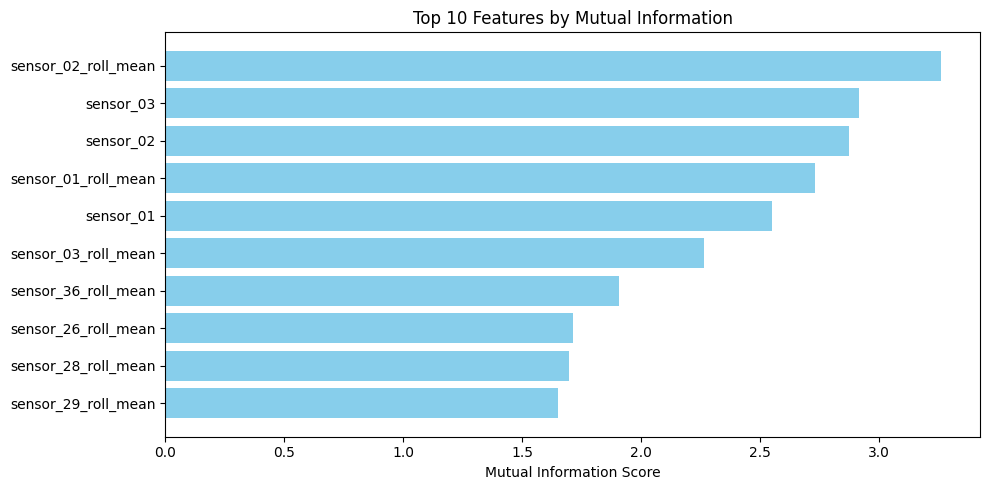

In [5]:
# 3A/ Visualize Top 10 Features by Mutual Information

top_features = mi_df.head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_features['feature'][::-1], top_features['mi_score'][::-1], color='skyblue')
plt.xlabel('Mutual Information Score')
plt.title('Top 10 Features by Mutual Information')
plt.tight_layout()
plt.show()

## 4) Stratified Train-Test Split

In [6]:
# 4/ Stratified Train-Test Split by RUL Distribution

print_header("4/ STRATIFIED TRAIN-TEST SPLIT BY RUL DISTRIBUTION")

if os.path.exists('pump_features_rul.csv'):
    # Load features from CSV
    df_features = pd.read_csv('pump_features_rul.csv')
    print("Features loaded from pump_features_rul.csv\n")
else:
    print("pump_features_rul.csv not found. run previous cells to generate features.\n")

# Separate features and target
if 'rul' in df_features.columns:
    X_all = df_features.drop('rul', axis=1)
    y_all = df_features['rul']
else:
    X_all = df_features.copy()
    y_all = y.copy()

# Bin RUL values for stratification
rul_bins = pd.cut(y_all, bins=10, labels=False)

# Stratified split
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in splitter.split(X_all, rul_bins):
    X_train = X_all.iloc[train_idx]
    X_test = X_all.iloc[test_idx]
    # ------------------------------
    y_train = y_all.iloc[train_idx]
    y_test = y_all.iloc[test_idx]

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Validation
print("-" * 40)
print("Train-Test Split Validation")
print("-" * 40)

# Split
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train RUL distribution:")
print(pd.Series(y_train).value_counts(bins=10, sort=False))
print("Test RUL distribution:")
print(pd.Series(y_test).value_counts(bins=10, sort=False))

# Scaling
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print_footer("DATA SPLIT AND SCALING COMPLETE")


4/ STRATIFIED TRAIN-TEST SPLIT BY RUL DISTRIBUTION
Features loaded from pump_features_rul.csv

----------------------------------------
Train-Test Split Validation
----------------------------------------
Train shape: (133152, 150) Test shape: (33289, 150)
Train RUL distribution:
(-0.838, 83.747]      28140
(83.747, 167.493]     24721
(167.493, 251.24]     18513
(251.24, 334.987]     13725
(334.987, 418.733]    12060
(418.733, 502.48]      8186
(502.48, 586.227]      8039
(586.227, 669.973]     8041
(669.973, 753.72]      7706
(753.72, 837.467]      4021
Name: count, dtype: int64
Test RUL distribution:
(-0.805, 83.778]      7038
(83.778, 167.523]     6181
(167.523, 251.268]    4627
(251.268, 335.013]    3430
(335.013, 418.758]    3014
(418.758, 502.503]    2047
(502.503, 586.248]    2010
(586.248, 669.993]    2010
(669.993, 753.738]    1927
(753.738, 837.483]    1005
Name: count, dtype: int64
X_train_scaled shape: (133152, 150)
X_test_scaled shape: (33289, 150)

----------------------

## 5) Parameter Selection

In [7]:
# 5/ Hyperparameter Optimization with RandomizedSearchCV



print_header("5/ HYPERPARAMETER OPTIMIZATION WITH RANDOMIZEDSEARCHCV")

top_k = 35
selected_cols = mi_df.head(top_k)['feature'].tolist()
X_train_sel = X_train[selected_cols].copy()
X_test_sel  = X_test[selected_cols].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

# Save scaler object for ROS2
joblib.dump(scaler, "scaler_pump_top35_features.pkl")

val_idx = int(0.9 * len(X_train_scaled))
X_tr = X_train_scaled[:val_idx]
y_tr = y_train.iloc[:val_idx]
X_va = X_train_scaled[val_idx:]
y_va = y_train.iloc[val_idx:]

param_grid = {
                'n_estimators': [800, 1200],
                'max_depth': [4, 6],
                'learning_rate': [0.02, 0.05],
                'subsample': [0.8, 1.0],
                'colsample_bytree': [0.8, 1.0],
            }

xgb_base = xgb.XGBRegressor(
                                random_state=42,
                                tree_method='hist',
                                eval_metric='mae',
                                early_stopping_rounds=30,
                                n_jobs=-1
                            )

random_search = RandomizedSearchCV(
                                        xgb_base,
                                        param_grid,
                                        n_iter=20,
                                        cv=2, 
                                        verbose=1,
                                        n_jobs=-1,
                                        random_state=42,
                                    )



print("Starting Randomized Search...")
random_search.fit(
                    X_tr,
                    y_tr,
                    eval_set=[(X_va, y_va)],
                    verbose=False
                )

print("-"*40)
print("Randomized Search Complete")
print("Best MAE:", -random_search.best_score_)
print("Best Params:", random_search.best_params_)

print_footer("HYPERPARAMETER OPTIMIZATION COMPLETE")


5/ HYPERPARAMETER OPTIMIZATION WITH RANDOMIZEDSEARCHCV
Starting Randomized Search...
Fitting 2 folds for each of 20 candidates, totalling 40 fits


----------------------------------------
Randomized Search Complete
Best MAE: -0.996207592828769
Best Params: {'subsample': 1.0, 'n_estimators': 1200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

----------------------------------------------------------------------
HYPERPARAMETER OPTIMIZATION COMPLETE
----------------------------------------------------------------------


## 6) XGBoost Training

In [8]:
# 6/ Model Training and Evaluation

print_header("6/ XGBOOST MODEL TRAINING")

# main model setup with best parameters from RandomizedSearchCV
model = xgb.XGBRegressor(
                            n_estimators=random_search.best_params_['n_estimators'],
                            learning_rate=random_search.best_params_['learning_rate'],
                            max_depth=random_search.best_params_['max_depth'],
                            subsample=random_search.best_params_['subsample'],
                            colsample_bytree=random_search.best_params_['colsample_bytree'],
                            reg_lambda=1.0,
                            reg_alpha=0.1,
                            random_state=42,
                            tree_method='hist',
                            eval_metric='mae',
                            early_stopping_rounds=50,
                            n_jobs=-1
                        )

# train-validation split
val_split_idx = int(0.9 * len(X_train_scaled))
X_train_final = X_train_scaled[:val_split_idx]
y_train_final = y_train.iloc[:val_split_idx]
X_val = X_train_scaled[val_split_idx:]
y_val = y_train.iloc[val_split_idx:]

# training
print("Training started...")
model.fit(
            X_train_final,
            y_train_final,
            eval_set=[(X_val, y_val)],
            verbose=50,
        )

# evaluation on test data
y_pred = model.predict(X_test_scaled)

mae = MAE(y_test, y_pred)
rmse = R_MSE(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print_kv([
            ("Test MAE", f"{mae:.2f} cycles"),
            ("Test RMSE", f"{rmse:.2f} cycles"),
            ("Test R2", f"{r2:.4f}"),
            ("Target", "MAE < 10 & R2 > 0")
        ])

# save model
model.save_model("pump_rul_xgb.json")
print("Model saved: pump_rul_xgb.json")

# validation
assert mae < 20, "Model too inaccurate!"
print("XGBoost training completed successfully.")

print_footer("XGBOOST TRAINING COMPLETE")



6/ XGBOOST MODEL TRAINING
Training started...
[0]	validation_0-mae:184.41263
[50]	validation_0-mae:34.99831
[100]	validation_0-mae:19.71076
[150]	validation_0-mae:16.23148
[200]	validation_0-mae:13.81220
[250]	validation_0-mae:11.97001
[300]	validation_0-mae:10.84563
[350]	validation_0-mae:10.01780
[400]	validation_0-mae:9.35695
[450]	validation_0-mae:8.88188
[500]	validation_0-mae:8.48399
[550]	validation_0-mae:8.14435
[600]	validation_0-mae:7.84262
[650]	validation_0-mae:7.57367
[700]	validation_0-mae:7.33852
[750]	validation_0-mae:7.15509
[800]	validation_0-mae:6.98206
[850]	validation_0-mae:6.82926
[900]	validation_0-mae:6.69541
[950]	validation_0-mae:6.56547
[1000]	validation_0-mae:6.45512
[1050]	validation_0-mae:6.34650
[1100]	validation_0-mae:6.25534
[1150]	validation_0-mae:6.16711
[1199]	validation_0-mae:6.06838
Test MAE  : 6.07 cycles
Test RMSE : 11.98 cycles
Test R2   : 0.9972
Target    : MAE < 10 & R2 > 0
Model saved: pump_rul_xgb.json
XGBoost training completed successfull

## 7) Degredation Test


7/ DEGRADATION TEST: MODEL EVALUATION AND VISUALIZATION
Degradation Test Results
----------------------------------------
Test MAE       : 6.07 cycles
Test RMSE      : 11.98 cycles
Test R2        : 0.9972
----------------------------------------
Model performance is acceptable for RUL prediction.

----------------------------------------------------------------------
DEGRADATION TEST COMPLETE
----------------------------------------------------------------------


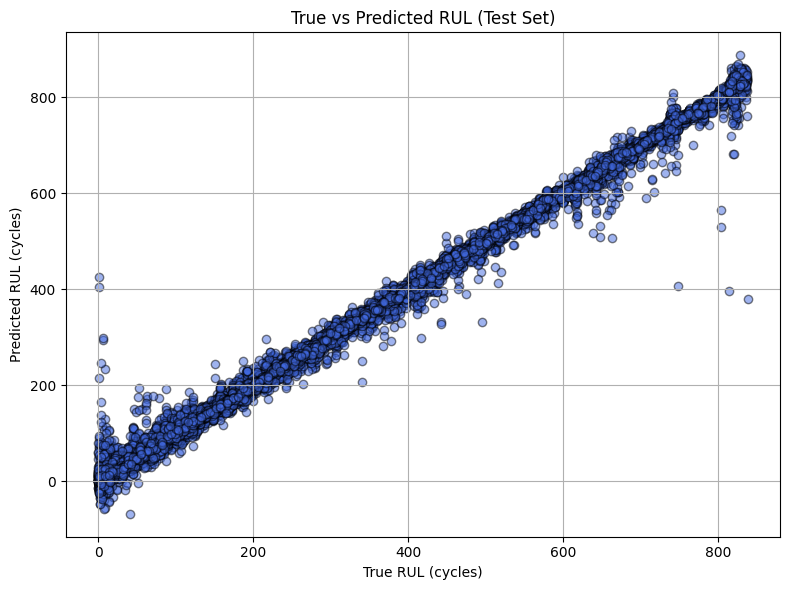

In [9]:
# 7/ Degradation Test: Model Evaluation and Visualization

print_header("7/ DEGRADATION TEST: MODEL EVALUATION AND VISUALIZATION")


# Predict and evaluate
y_pred = model.predict(X_test_scaled)
mae = MAE(y_test, y_pred)
rmse = R_MSE(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Validation: Print metrics
print("Degradation Test Results")
print("-" * 40)
print(f"{'Test MAE':<15}: {mae:.2f} cycles")
print(f"{'Test RMSE':<15}: {rmse:.2f} cycles")
print(f"{'Test R2':<15}: {r2:.4f}")
print("-" * 40)

# Check if MAE is acceptable (example threshold: 10 cycles)
if mae < 10:
    print("Model performance is acceptable for RUL prediction.")
else:
    print("Warning: Model MAE is higher than expected.")

print_footer("DEGRADATION TEST COMPLETE")

# Visualization: Scatter Plot of True vs Predicted RUL
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue', edgecolor='k')
plt.xlabel("True RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("True vs Predicted RUL (Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

## 8) Drift Test

In [10]:
# 8/ Model Drift Validation

print_header("8/ MODEL DRIFT VALIDATION")

# helper functions
def find_file_recursive(patterns, root="."):
    """Return first match for any pattern (recursive)."""
    for pat in patterns:
        matches = glob.glob(os.path.join(root, "**", pat), recursive=True)
        if matches:
            return matches[0]
    return None

def load_artifacts(root="."):
    """Locate and load feature CSV, scaler (.pkl) and model (.json) for pump RUL."""
    feat_patterns = ["pump_features_rul.csv", "*features*rul*.csv"]
    scaler_patterns = ["scaler_pump_top35_features.pkl", "scaler_pump_features.pkl", "*.pkl"]
    model_patterns = ["pump_rul_xgb_final.json", "pump_rul_xgb.json", "*.json"]
    
    feat_file = find_file_recursive(feat_patterns, root=root)
    scaler_file = find_file_recursive(scaler_patterns, root=root)
    model_file = find_file_recursive(model_patterns, root=root)
    
    if not feat_file:
        raise FileNotFoundError("pump_features_rul.csv not found. Run previous cells.")
    if not scaler_file:
        raise FileNotFoundError("Scaler .pkl not found. Run previous cells.")
    if not model_file:
        raise FileNotFoundError("Model .json not found. Run previous cells.")

    df = pd.read_csv(feat_file)
    scaler_obj = joblib.load(scaler_file)
    model = xgb.XGBRegressor()
    model.load_model(model_file)
    
    return df, scaler_obj, model, feat_file, scaler_file, model_file

def ks_wasserstein_report(X_ref, X_target, feature_names):
    """Return DataFrame with KS stat/p-value and Wasserstein distance per feature."""
    rows = []
    for i, name in enumerate(feature_names):
        ref_col = X_ref[:, i]
        tgt_col = X_target[:, i]
        ks_stat, ks_p = ks_2samp(ref_col, tgt_col)
        w_dist = wasserstein_distance(ref_col, tgt_col)
        rows.append((name, ks_stat, ks_p, w_dist, ref_col.mean(), tgt_col.mean()))
    return pd.DataFrame(rows, columns=["feature", "ks_stat", "ks_p", "wasserstein", "ref_mean", "target_mean"])

def performance_by_rul_bins(y_true, y_pred, n_bins=6):
    """Return MAE per RUL quantile bin."""
    bins = pd.qcut(y_true, q=n_bins, duplicates='drop')
    results = []
    for bin_label, idx in bins.groupby(bins).groups.items():
        idx_list = list(idx)
        mae_val = MAE(y_true.iloc[idx_list], y_pred[idx_list])
        results.append((str(bin_label), len(idx_list), mae_val))
    return pd.DataFrame(results, columns=["rul_bin", "count", "mae"])


# Application: Load, Split, Scale, Predict

# load artifacts
df_features, scaler, model, feat_path, scaler_path, model_path = load_artifacts(root=".")
print("Loaded artifacts:")
print(f"  Features : {os.path.basename(feat_path)}")
print(f"  Scaler   : {os.path.basename(scaler_path)}")
print(f"  Model    : {os.path.basename(model_path)}")

# prepare data
assert 'rul' in df_features.columns, "rul column missing in feature CSV"
selected_cols = mi_df.head(35)['feature'].tolist()  # top 35 features
X = df_features[selected_cols].copy()
y = df_features['rul'].copy()

# time-based split (last 20% as test)
split_idx = int(0.8 * len(X))

X_time_train = X.iloc[:split_idx].reset_index(drop=True)
y_time_train = y.iloc[:split_idx].reset_index(drop=True)

X_time_test  = X.iloc[split_idx:].reset_index(drop=True)
y_time_test  = y.iloc[split_idx:].reset_index(drop=True)

# stratified split by RUL bins
rul_bins = pd.cut(y, bins=5, labels=False)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in sss.split(X, rul_bins):
    X_strat_train = X.iloc[train_idx].reset_index(drop=True)
    y_strat_train = y.iloc[train_idx].reset_index(drop=True)
    X_strat_test  = X.iloc[test_idx].reset_index(drop=True)
    y_strat_test  = y.iloc[test_idx].reset_index(drop=True)

# scale all splits
X_time_train_s = scaler.transform(X_time_train)
X_time_test_s  = scaler.transform(X_time_test)

X_strat_train_s = scaler.transform(X_strat_train)
X_strat_test_s  = scaler.transform(X_strat_test)

# predictions
y_pred_time = model.predict(X_time_test_s)
y_pred_strat = model.predict(X_strat_test_s)

# drift report (stratified split)
drift_df = ks_wasserstein_report(X_strat_train_s, X_strat_test_s, selected_cols)
drift_df['ks_significant'] = drift_df['ks_p'] < 0.05
drift_df = drift_df.sort_values('wasserstein', ascending=False).reset_index(drop=True)

# feature importance
importance_vals = model.feature_importances_
importance_df = pd.DataFrame({
                                "feature": selected_cols,
                                "importance": importance_vals
                            }).sort_values("importance", ascending=False).reset_index(drop=True)

# performance metrics
metrics_dict = {
                    "time_test_mae": float(MAE(y_time_test, y_pred_time)),
                    "time_test_r2": float(r2_score(y_time_test, y_pred_time)),
                    "strat_test_mae": float(MAE(y_strat_test, y_pred_strat)),
                    "strat_test_r2": float(r2_score(y_strat_test, y_pred_strat))
                }

# MAE by RUL bin (time test)
mae_by_bin = performance_by_rul_bins(y_time_test.reset_index(drop=True), y_pred_time, n_bins=6)

# save reports
out_dir = "./diagnostics_out"
os.makedirs(out_dir, exist_ok=True)
drift_df.to_csv(os.path.join(out_dir, "ks_drift_report.csv"), index=False)
importance_df.to_csv(os.path.join(out_dir, "feature_importance.csv"), index=False)
pd.DataFrame([metrics_dict]).to_csv(os.path.join(out_dir, "performance_metrics.csv"), index=False)
mae_by_bin.to_csv(os.path.join(out_dir, "mae_by_rul_bin.csv"), index=False)

# Validation: Print Summary

print("\nMODEL DRIFT & PERFORMANCE SUMMARY")
print("="*40)
print(f"Total features tested       : {len(selected_cols)}")
significant_drift = drift_df['ks_significant'].sum()
print(f"KS significant drift (p<0.05): {int(significant_drift)} ({significant_drift/len(selected_cols)*100:.1f}%)")

print("\nTop 8 drifted features (Wasserstein):")
top_drift = drift_df.head(8)[['feature', 'wasserstein', 'ks_p', 'ref_mean', 'target_mean']]
print(top_drift.to_string(index=False, float_format="%.4f"))

print("\nTop 10 important features:")
top_imp = importance_df.head(10)[['feature', 'importance']]
print(top_imp.to_string(index=False, float_format="%.4f"))

print("\nPerformance on test sets:")
for key, val in metrics_dict.items():
    print(f"  {key:<15}: {val:.4f}")

print("\nMAE by RUL bin (time-based test):")
print(mae_by_bin.to_string(index=False, float_format="%.3f"))

print(f"\nAll reports saved in: {out_dir}/")
print_footer("MODEL DRIFT VALIDATION COMPLETE")


8/ MODEL DRIFT VALIDATION
Loaded artifacts:
  Features : pump_features_rul.csv
  Scaler   : scaler_pump_top35_features.pkl
  Model    : pump_rul_xgb.json

MODEL DRIFT & PERFORMANCE SUMMARY
Total features tested       : 35
KS significant drift (p<0.05): 0 (0.0%)

Top 8 drifted features (Wasserstein):
            feature  wasserstein   ks_p  ref_mean  target_mean
sensor_42_roll_mean       0.0127 0.4599   -0.0013       0.0094
          sensor_42       0.0117 0.5407   -0.0013       0.0087
sensor_49_roll_mean       0.0094 0.0618    0.0002       0.0056
          sensor_49       0.0093 0.0739    0.0003       0.0051
          sensor_45       0.0089 0.1119   -0.0015       0.0051
          sensor_29       0.0077 0.3737   -0.0007       0.0070
sensor_33_roll_mean       0.0074 0.6757   -0.0014       0.0058
sensor_03_roll_mean       0.0074 0.2914    0.0003       0.0031

Top 10 important features:
            feature  importance
sensor_22_roll_mean      0.1584
sensor_23_roll_mean      0.0817
sensor_

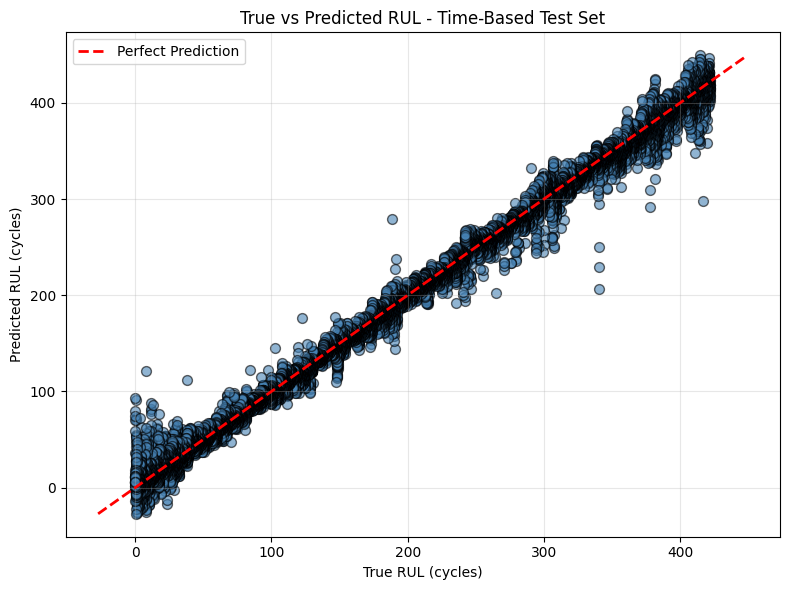

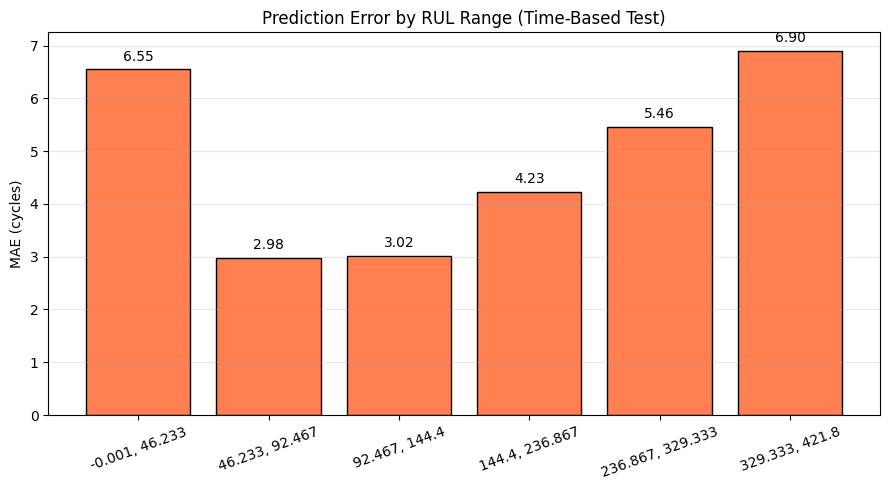

In [11]:
# 8A/ Visualization

# scatter plot: True vs Predicted RUL (time-based test)
plt.figure(figsize=(8, 6))
plt.scatter(y_time_test, y_pred_time, alpha=0.6, color='steelblue', edgecolor='k', s=50)
min_val = min(y_time_test.min(), y_pred_time.min())
max_val = max(y_time_test.max(), y_pred_time.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("True RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("True vs Predicted RUL - Time-Based Test Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# MAE by RUL Bin

plt.figure(figsize=(9, 5))
bars = plt.bar(range(len(mae_by_bin)), mae_by_bin['mae'], color='coral', edgecolor='black')
plt.xticks(range(len(mae_by_bin)), [b.replace('(', '').replace(']', '') for b in mae_by_bin['rul_bin']], rotation=20)
plt.ylabel("MAE (cycles)")
plt.title("Prediction Error by RUL Range (Time-Based Test)")
plt.grid(True, axis='y', alpha=0.3)

# add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f"{height:.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()